# Imports

In [1]:
#set path to DeePEn
import os.path

os.chdir("path to DeePEn")

In [2]:
#import dependencies
import copy
import requests
import zipfile
import io
import json
import math
import os
import subprocess
import sys

import numpy as np
import pandas as pd

from scipy import stats
from scipy.interpolate import make_interp_spline

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.pyplot import cm
import matplotlib.ticker as mtick

import seaborn as sns

In [3]:
# import methods
sys.path.append('./utils')
from DeePEn_evaluate import load_results, calc_metric_depth
from DeePEn_analyse import plot_multi_model_multi_metric_DeePEn, table_multi_model_multi_metric_DeePEn

In [4]:
# run prepare_data.py if the splits were not created yet
if not os.path.isdir('./data/splits'):
    subprocess.run(['python', './data/prepare_data.py'])

In [5]:
# Check: If ./results exists, contains main zip shards, and does NOT contain a main directory, unzip
main_zip_1 = './results/main_1.zip'
main_zip_2 = './results/main_2.zip'
main_dir = './results/main'

def unzip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        zipf.extractall(extract_to)

if os.path.isdir('./results') and os.path.isfile(main_zip_1) and os.path.isfile(main_zip_2) and not os.path.isdir(main_dir):
    unzip(main_zip_1, main_dir)
    unzip(main_zip_2, main_dir)
    print(f'Extracted {main_zip_1.split("/")[-1]} and {main_zip_2.split("/")[-1]} to {main_dir}')
elif os.path.isdir(main_dir):
    print(f'{main_dir} was already extracted previously')    
else:
    print(f'{main_zip} is missing')

./results/main was already extracted previously


# Add your own model results

to add your own model results you need to follow these steps:

1. train your model on the provided data splits (at ./data/splits)
1. add a new model directory to ./results/main
1. add your results in .csv format to this model directory
    * csv names need to match the respective dataset name
    * mandatory columns are "mutant", "set" and at least one results column (needs to contain "seed_" in column name)
    
Afterwards you can provide the chosen model name to analyis methods below

## Add a new dataset

bringing in new datasets quickly was not our focus, as it means one needs to compute predictions for a number of existing methods to have a meaningful comparison. 
If this is still required you can bring in either 
1. a prepared split files (like here ./data/splits/) 
or 
1. a single raw file, like the ones we proivided (./data/raw/)

# Analyse main results

In [6]:
# Get a list of all datasets in the directory
files = os.listdir("./data/splits")
files

['CAPSD_AAV2S_Sinai_2021',
 'GFP_AEQVI_Sarkisyan_2016',
 'HIS7_YEAST_Pokusaeva_2019',
 'PHOT_CHLRE_Chen_2023']

## DeePEn results - box plots

In [7]:
'''
plot_multi_model_multi_metric_DeePEn(methods, 
                                     datas, 
                                     metric = ["AUCPR" , "spearman_func"], 
                                     main = True, 
                                     colors = None)

Args:
    methods (list): models to include (e.g. 'PT5-LoRA_rank')
    datas (list): datasets to include (e.g. 'CAPSD_AAV2S_Sinai_2021')
    metric (list): metrics to include, valid values are:
            "AUCPR": Area under the precision-recall curve 
            "spearman_func": Spearman's rank correlation coefficient for all functional sequences (DMS_score_bin = 1)
            "spearman_all": Spearman's rank correlation coefficient for all sequences
            "NDCG@X": NDCG@X%func, NDCG on the top X% of functional sequences (DMS_score_bin = 1)
            "TOP_Y": TOPY%func, Recall on the top Y% of functional sequences (DMS_score_bin = 1) 
    main (bool): True > takes results from /results/main/, False > takes results from /results/SOM/
    colors (list): None > take the colors we used for Fig. 3, allows to add a custom list of matplotlib color names instead 
        the colors we used are:
        "slategrey" ,    "grey",
        "darkgreen",    "olive",
        "orangered",    "firebrick",
        "aqua",    "royalblue",
        "goldenrod",    "darkorange"
Returns:
    the method displays the plot

''';

E.g. to get the box plots for 

- our four DeePEn datasets
- our four metrics
- only compare the MAVE-NN and METL-models
- same colors as in Fig. 3

one would use:

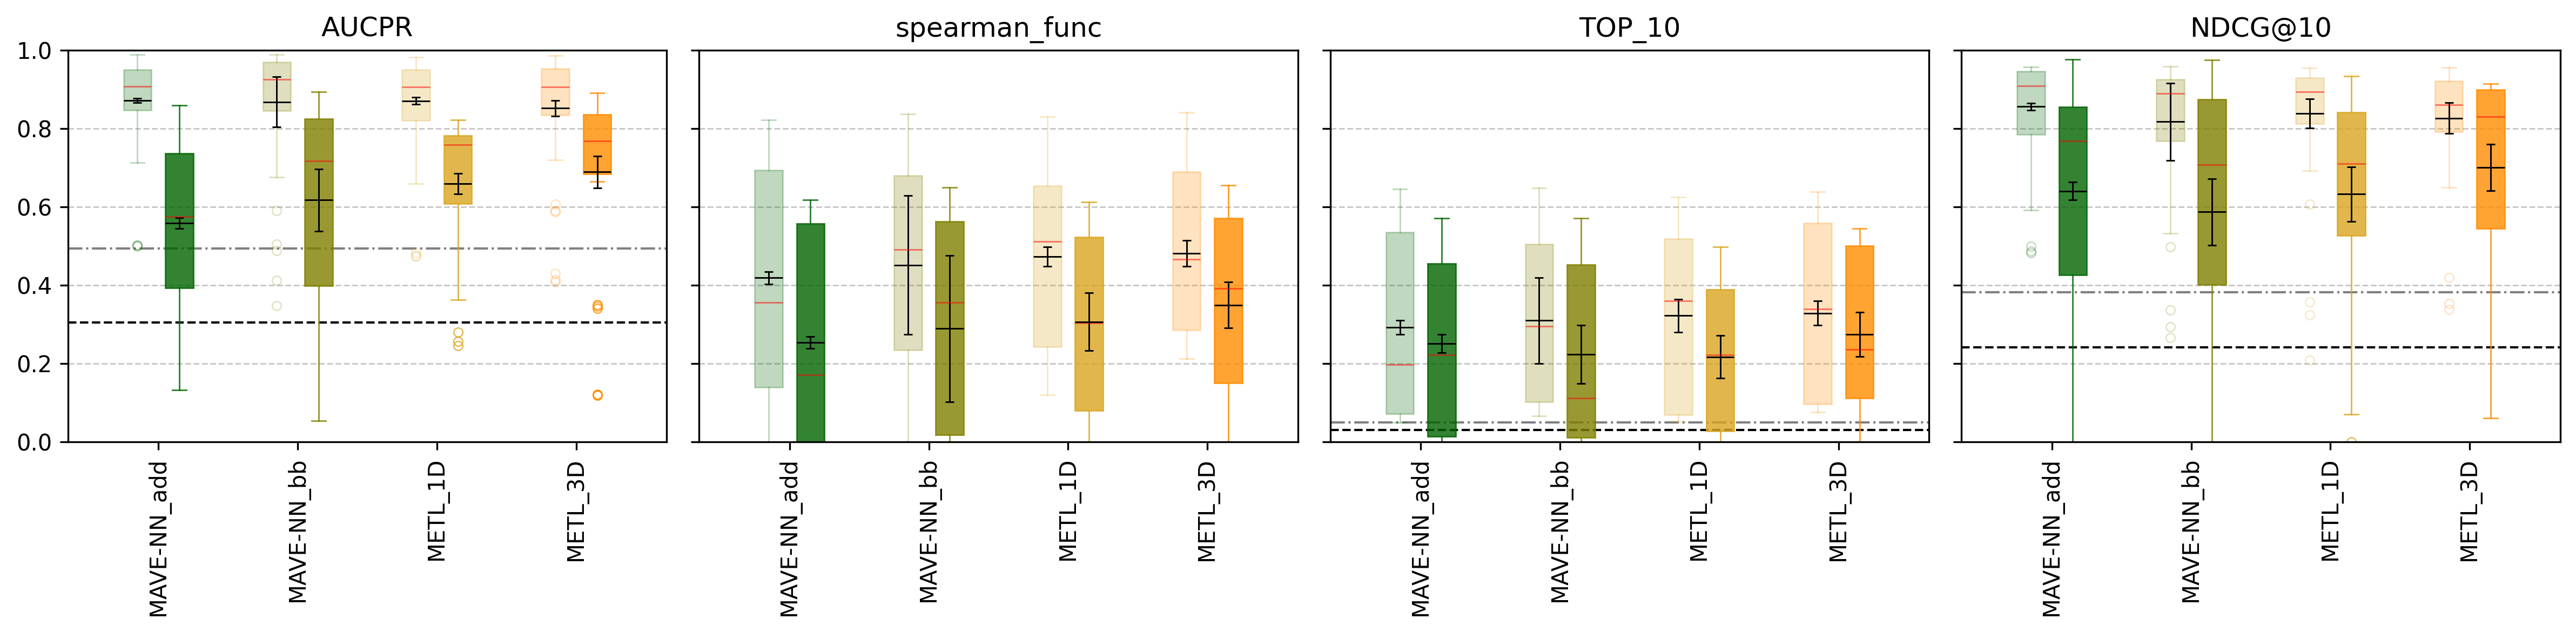

In [8]:
plot_multi_model_multi_metric_DeePEn(methods = ['MAVE-NN_add','MAVE-NN_bb','METL_1D','METL_3D'], 
                                     datas = files, 
                                     metric = ["AUCPR" , "spearman_func", "TOP_10", "NDCG@10"], 
                                     main = True, 
                                     colors = ['darkgreen','olive','goldenrod','darkorange'])

## DeePEn results - table format

In [9]:
'''
table_multi_model_multi_metric_DeePEn(methods, 
                                     datas, 
                                     metric = ["AUCPR" , "spearman_func"], 
                                     main = True, 
                                     random_baseline = False, 
                                     perfect_classifier_baseline = False, 
                                     aggregate = True, 
                                     percentage = True, 
                                     digits = 2)

Args:
    methods (list): models to include (e.g. 'PT5-LoRA_rank')
    datas (list): datasets to include (e.g. 'CAPSD_AAV2S_Sinai_2021')
    metric (list): metrics to include, valid values are:
            "AUCPR": Area under the precision-recall curve 
            "spearman_func": Spearman's rank correlation coefficient for all functional sequences (DMS_score_bin = 1)
            "spearman_all": Spearman's rank correlation coefficient for all sequences
            "NDCG@X": NDCG@X%func, NDCG on the top X% of functional sequences (DMS_score_bin = 1)
            "TOP_Y": TOPY%func, Recall on the top Y% of functional sequences (DMS_score_bin = 1) 
    main (bool): True > takes results from /results/main/, False > takes results from /results/SOM/
    random_baseline (bool): adds the random_baseline to your methods, which calculates metrics for random predictions
                            assigns random predictions for each row of each datasets, 
                            metrics are caluclated across 1000 random assignments (which makes this compute intensive)
    perfect_classifier_baseline (bool): adds the perfect_classifier_baseline to your methods, 
                            which calculates metrics for a perfect binary classifier with random ranking of functional sequences
                            assigns random predictions (>0) for each functional sequence and 0 for non-functional sequences, 
                            metrics are caluclated across 1000 random assignments (which makes this compute intensive)                            
    aggregate (bool): whether to provide the average performance per model (over different random seeds and depth bins)
                      False > returns a list of dataframes with detailed results (on a single depth, seed basis)
    percentage (bool): whether to multiply by 100 (after rounding to digits)
    digits (int): round to i decimal places
    
Returns:
    dataframe with the calculated metrics

''';

E.g. getting the results for 

- the GFP dataset
- all five possible metrics
- all models 
- same colors as in Fig. 3
- averaged over random seeds
- in float values instead of percentages

one would use:

In [10]:
models = ['SBI',         '1-hot',
         'MAVE-NN_add',         'MAVE-NN_bb',
         'PT5-LoRA_reg',         'PT5-LoRA_rank',
         'PT5-Emb',         'PT5-Emb_evo',
         'METL_1D',         'METL_3D']

In [11]:
table_multi_model_multi_metric_DeePEn(methods = models, 
                                      datas = ['GFP_AEQVI_Sarkisyan_2016'], 
                                      metric = ["spearman_all","AUCPR","spearman_func","TOP_10", "NDCG@10"], 
                                      main = True, 
                                      random_baseline = False, 
                                      perfect_classifier_baseline = False, 
                                      aggregate = True, 
                                      percentage = True, 
                                      digits = 2)

,method,depth,spearman_all,AUCPR,spearman_func,TOP_10,NDCG@10
0,SBI,shallow (5-9),27 ± 0,37 ± 0,17 ± 0,7 ± 0,40 ± 0
1,SBI,higher depth (10+),2 ± 0,8 ± 0,28 ± 0,0 ± 0,12 ± 0
2,1-hot,shallow (5-9),-2 ± 13,20 ± 6,-1 ± 11,1 ± 1,13 ± 23
3,1-hot,higher depth (10+),-1 ± 2,3 ± 1,-8 ± 1,0 ± 0,0 ± 0
4,MAVE-NN_add,shallow (5-9),48 ± 0,97 ± 1,66 ± 1,40 ± 4,95 ± 1
5,MAVE-NN_add,higher depth (10+),6 ± 1,85 ± 2,55 ± 3,52 ± 20,97 ± 1
6,MAVE-NN_bb,shallow (5-9),49 ± 10,97 ± 1,64 ± 2,41 ± 8,95 ± 1
7,MAVE-NN_bb,higher depth (10+),8 ± 9,86 ± 2,53 ± 7,56 ± 0,97 ± 1
8,PT5-LoRA_reg,shallow (5-9),48 ± 1,95 ± 2,54 ± 4,31 ± 9,94 ± 1
9,PT5-LoRA_reg,higher depth (10+),6 ± 3,81 ± 5,45 ± 15,38 ± 20,95 ± 2


## DeePEn results - Single result

In [12]:
'''
calc_metric_depth(  path, 
                    data, 
                    metric="AUCPR")

Args:
    path (str): a single model path (e.g. './results/main/PT5-LoRA_rank')
    datas (str): a single dataset (e.g. 'CAPSD_AAV2S_Sinai_2021')
    metric (str): a single metric metric to calculate, valid values are:
            "AUCPR": Area under the precision-recall curve 
            "spearman_func": Spearman's rank correlation coefficient for all functional sequences (DMS_score_bin = 1)
            "spearman_all": Spearman's rank correlation coefficient for all sequences
            "NDCG@X": NDCG@X%func, NDCG on the top X% of functional sequences (DMS_score_bin = 1)
            "TOP_Y": TOPY%func, Recall on the top Y% of functional sequences (DMS_score_bin = 1) 

Returns:
    a dataframe with the specified results 

''';

E.g. getting the results for 

- the AAV capsid dataset
- NDCG on the top 10%
- the PT5-LoRA Rank. model

one would use:

In [13]:
calc_metric_depth(path =   './results/main/PT5-LoRA_rank', 
                  data =   'CAPSD_AAV2S_Sinai_2021', 
                  metric = 'NDCG@10')

,depth,x,examples,exmpl_function,frac_function,1,2,3,mean
0,4,4,6646,4504,0.677701,0.867513,0.874493,0.87533,0.872445
1,5,5,6298,3772,0.59892,0.869008,0.863954,0.877244,0.870069
2,6,6,5396,2584,0.478873,0.829427,0.835681,0.82787,0.830993
3,7,7,858,398,0.463869,0.869992,0.887257,0.878086,0.878445
4,8,8,739,237,0.320704,0.794605,0.770213,0.765378,0.776732
5,9,9,651,141,0.21659,0.576126,0.585617,0.6426,0.601448
6,10,10,583,92,0.157804,0.709967,0.708927,0.534557,0.65115
7,11-28,11,2886,91,0.031532,0.382237,0.301354,0.323636,0.335742
